# FORESEE Models: Dark Higgs

## Load Libraries 

In [1]:
import sys, os
src_path = "../../"
sys.path.append(src_path)

import numpy as np
from src_scalar.foresee import Foresee, Utility, Model
from matplotlib import pyplot as plt

## 1. Specifying the Model

The phenomenology of the dark Higgs $\phi$ can be described by the following Lagrangian

\begin{equation}
 \mathcal{L} =  - \color{red}{m_{\phi}}^2\ \phi^2  - \sin\color{red}{\theta} \ \sum \ (m \ /\ v )\ \bar f \ f  \ \phi - \lambda \ v \ h \phi \phi
\end{equation}

with the dark Higgs mass $m_{\phi}$ and the mixing angle $\theta$ as free parameters. Additionally, one can consider an the tri-linear coupling $\lambda$ as a third parameter of the theory. In the followig, we will keep fixed at $\lambda=0.0033$ corresponding to BR$(h \to \phi\phi)=5\%$.  References [1710.09387](https://arxiv.org/pdf/1710.09387.pdf) and [1811.12522](https://arxiv.org/pdf/1811.12522.pdf) are used for calculation of branching fraction to Dark Higgs as well as decay and lifetime of Dark Higgs boson.

In [2]:
energy = "400"
unit = "GeV"
modelname = "DarkHiggs"
model = Model(modelname)

**Production** The Dark Higgs is mainly produced in the flavour changing 2-body decay of $B$-mesons $B \to X_s \phi$. This process includes all b-flavoured hadrons and all strange-flavored decay products. 

\begin{equation}
    \text{BR}(b \to X_s\  \phi) = 5.6 \times (1-m_\phi^2/m_B^2)^2 \times \theta^2
\end{equation}

In the following, we model heavy hadron production using the `POWHEG+Pythia8` predicions.

In [3]:
model.add_production_2bodydecay(
    pid0 = "511",
    pid1 = "130",
    br = "5.6 * coupling**2 * (1.-(mass/self.masses('pid0'))**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
)

model.add_production_2bodydecay(
    pid0 = "-511",
    pid1 = "130",
    br = "5.6 * coupling**2 * (1.-(mass/self.masses('pid0'))**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
)

model.add_production_2bodydecay(
    pid0 = "521",
    pid1 = "321",
    br = "5.6 * coupling**2 * (1.-(mass/self.masses('pid0'))**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
)

model.add_production_2bodydecay(
    pid0 = "-521",
    pid1 = "321",
    br = "5.6 * coupling**2 * (1.-(mass/self.masses('pid0'))**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
)

If the tri-linear coupling does not vanish, the dark Higgs can also be produced in 2-body decays of the Higgs boson: $h \to \phi \phi$. The corresponding branching fraction (for our choice of $\lambda=0.0033$) is

\begin{equation}
    \text{BR}(h \to \phi \  \phi) = 4700 \lambda^2 = 0.05
\end{equation}

Here the line `pid1="0"` means that the second decay product is also the LLP of interest, and `scaling=0` indicates that the branching fraction is constant wrt. the coupling $\theta$. Since we have two $\phi$ in the final state, we include an additional factor 2 in the branching fraction.  

In [4]:
#model.add_production_2bodydecay(
#    pid0 = "25",
#    pid1 = "0",
#    br = "2*0.05",
#    generator = ["Pythia8"],
#    energy = energy,
#    nsample = 200,
#    scaling = 0,
#)

The dark Higgs can also be produced in 3-body decays $B \to X_s \phi \phi$ via an offshell Higgs boson. This can be added using the function `add_production_3bodydecay()`. It requires to provide `br` which is the differential branching fraction $d\text{BR}/(dq^2 \ d\cos\vartheta)$ where $q^2=(p_{\phi_1}+p_{\phi_2})^2$ and $\vartheta$ is the angle between $p_{\phi_1}$ in the restframe of $p_{\phi_1}+p_{\phi_2}$ and the direction of $p_{\phi_1}+p_{\phi_2}$ in the restframe of the $b$. Since the process is mediated by a an offshell scalar (the Higgs), there is no dependence on the angle $\cos\vartheta$. We can write for the branching ratio

\begin{equation}
    \frac{d\text{BR} (\phi)}{d q^2 d\cos\vartheta} 
    = \frac{(4.9\cdot 10^{-8} {\rm GeV}^{-2} \ \lambda)^2 m_b^3}{512 \ \pi^3 \  \Gamma_b} 
      \times \left(1-\frac{4 m_\phi^2}{q^2}\right)^{1/2} \!\!\!\!\! \times \left(1-\frac{q^2}{m_b^2}\right)^2
    = 3.68\cdot 10^{-10}  \times \left(1-\frac{4 m_\phi^2}{q^2}\right)^{1/2}  \!\!\!\!\! \times \left(1-\frac{q^2}{m_b^2}\right)^2
\end{equation}

Since we have two $\phi$ in the final state, we again multiply the BR by an additional factor 2. 
Furthermore, as the factor $3.68\cdot 10^{-10}$ assumed a hard-coded value of $m_b^3=4.5^3$ GeV$^3$, a factor of $(m_b/4.5)^3$ ensures consistency with the $m_b$ definition in `src/foresee.py`.

In [5]:
model.add_production_3bodydecay(
    label= "511_di",
    pid0 = "511",
    pid1 = "130",
    pid2 = "0",
    br = "7.37e-10*(self.masses('5')/4.5)**3*np.sqrt(1-4*mass**2/q**2)*(1-q**2/self.masses('5')**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
    scaling = 0, 
)

model.add_production_3bodydecay(
    label= "-511_di",
    pid0 = "-511",
    pid1 = "130",
    pid2 = "0",
    br = "7.37e-10*(self.masses('5')/4.5)**3*np.sqrt(1-4*mass**2/q**2)*(1-q**2/self.masses('5')**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
    scaling = 0, 
)

model.add_production_3bodydecay(
    label= "521_di",
    pid0 = "521",
    pid1 = "321",
    pid2 = "0",
    br = "7.37e-10*(self.masses('5')/4.5)**3*np.sqrt(1-4*mass**2/q**2)*(1-q**2/self.masses('5')**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
    scaling = 0, 
)

model.add_production_3bodydecay(
    label= "-521_di",
    pid0 = "-521",
    pid1 = "321",
    pid2 = "0",
    br = "7.37e-10*(self.masses('5')/4.5)**3*np.sqrt(1-4*mass**2/q**2)*(1-q**2/self.masses('5')**2)**2",
    generator = 'Geant4',
    energy = energy,
    nsample = 50,
    scaling = 0, 
)

**Decay:** Dark Higgs bosons can decay into all kinematically accessible light charged states.

We can now initiate FORESEE with the model that we just created. 

In [6]:
foresee = Foresee(path=src_path)
foresee.set_model(model=model)

## 2. Event Generation

In the following, we want to study one specific benchmark point with $m_{\phi}=1.5$ GeV and $\theta=10^{-4}$ and export events as a HEPMC file. 

First, we will produce the corresponding flux for this mass and a reference coupling $\theta_{ref}=1$.

In [7]:
masses = np.logspace(-2,0,100)
# for mass in masses:
#     foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=False, unit=unit, save_file=True)# plot=foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=True)

Next, let us define the configuration of the detector (in terms of position, size and luminosity). Here we choose FASER2 at the FPF. 

In [8]:
foresee.set_detector(
    distance=12, 
    selection="np.sqrt((x.x/2.5)**2 + (x.y/5)**2)<1", 
    length=50, unit=unit,
    luminosity=6e20/1.085e15, name="U1_X",
)

For our benchmark point, let us now look at how many particle decay inside the decay volume. We also export 1000 unweighted events as a HEPMC file. 

Let us plot the resulting energy distribution

## 3. Sensitivity Reach

In the following, we will obtain the projected sensitivity for the LLP model. For this, we first define a grid of couplings and masses, and then produce the corresponding fluxes. 

We can now plot the `production rate vs mass` using the `foresee.plot_production()` function.

Let us now scan over various masses and couplings, and record the resulting number of evets. Note that here we again consider the FASER2 configuration, which we set up before.

In [9]:
%%time
#get reach 
couplings = np.logspace(-15, 0, 110)
configuration, exp ='coupling_ellipse', 'ship'

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=1, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"3.npy",result)

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=2, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"3.npy",result)

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 6min 21s, sys: 328 ms, total: 6min 21s
Wall time: 6min 27s


In [10]:
%%time
#get reach 
mixings = np.logspace(-10, 0, 500)
configuration, exp ='mixing_ellipse', 'ship'

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=1, Us=mixings, g=0.01, coup=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"4.npy",result)

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=2, Us=mixings, g=0.01, coup=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"4.npy",result)

CPU times: user 1min 11s, sys: 44 ms, total: 1min 11s
Wall time: 1min 11s


We can now plot the results. For this, we first specify all detector setups for which we want to show result (filename in model/results directory, label, color, linestyle, opacity alpha for filled contours, required number of events).

/tmp/ipykernel_11017/4165402177.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


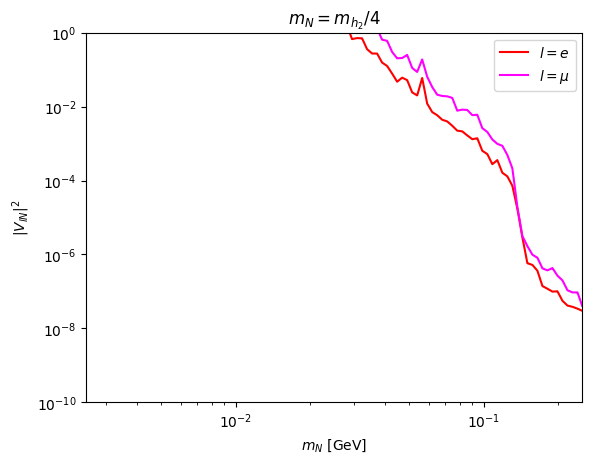

In [8]:
setups = [ 
    ["e_mixing_ellipse_ship_4", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_mixing_ellipse_ship_4", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses/4, couplings**2)
    n = np.log10(np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_N$ [GeV]") 
    plt.ylabel(r"$|V_{lN}|^2$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(0.25e-2, 0.25)
    plt.ylim(1e-10, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_mixing_ellipse"+".pdf")

/tmp/ipykernel_11017/3041177596.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


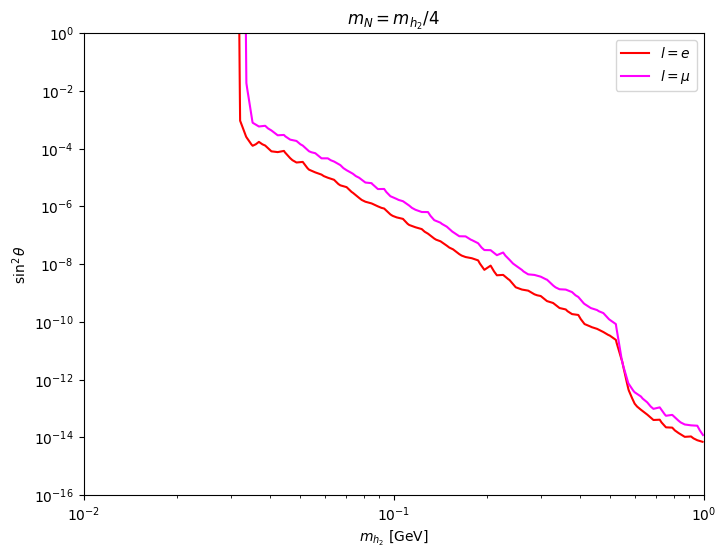

In [10]:
setups = [ 
    ["e_coupling_ellipse_ship_3", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_coupling_ellipse_ship_3", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses, couplings**2)
    n = np.log10(1e4*np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_{h_2}$ [GeV]") 
    plt.ylabel(r"$\sin^2 \theta$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(1e-2, 1)
    plt.ylim(1e-16, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_coupling_ellipse_3"+".pdf")

In [11]:
foresee.set_detector(
    distance=70, 
    selection="abs(x.x)<2.5 and abs(x.y)<5", 
    length=50, unit=unit,
    luminosity=6e20/1.085e15, name="U1_X",
)

For our benchmark point, let us now look at how many particle decay inside the decay volume. We also export 1000 unweighted events as a HEPMC file. 

Let us plot the resulting energy distribution

## 3. Sensitivity Reach

In the following, we will obtain the projected sensitivity for the LLP model. For this, we first define a grid of couplings and masses, and then produce the corresponding fluxes. 

We can now plot the `production rate vs mass` using the `foresee.plot_production()` function.

Let us now scan over various masses and couplings, and record the resulting number of evets. Note that here we again consider the FASER2 configuration, which we set up before.

In [14]:
%%time
#get reach 
couplings = np.logspace(-15, 0, 110)
configuration, exp ='coupling_front', 'ship'

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=1, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"3.npy",result)

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=2, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"3.npy",result)

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 4min 57s, sys: 116 ms, total: 4min 57s
Wall time: 4min 57s


We can now plot the results. For this, we first specify all detector setups for which we want to show result (filename in model/results directory, label, color, linestyle, opacity alpha for filled contours, required number of events).

In [ ]:
%%time
#get reach 
couplings = np.logspace(-15, 0, 110)
configuration, exp ='coupling_front', 'ship'

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=1, couplings=couplings, g=0.01, U=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"4.npy",result)

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=2, couplings=couplings, g=0.01, U=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"4.npy",result)

In [12]:
%%time
#get reach 
mixings = np.logspace(-10, 0, 500)
configuration, exp ='mixing_front', 'ship'

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=1, Us=mixings, g=0.01, coup=1e-5, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"5.npy",result)

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=2, Us=mixings, g=0.01, coup=1e-5, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"5.npy",result)

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 1min 6s, sys: 12.4 ms, total: 1min 6s
Wall time: 1min 6s


In [13]:
%%time
#get reach 
mixings = np.logspace(-10, 0, 500)
configuration, exp ='mixing_front', 'ship'

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=1, Us=mixings, g=0.01, coup=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"3.npy",result)

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=2, Us=mixings, g=0.01, coup=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"3.npy",result)

CPU times: user 1min 4s, sys: 4.1 ms, total: 1min 4s
Wall time: 1min 5s


/tmp/ipykernel_11017/244348127.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


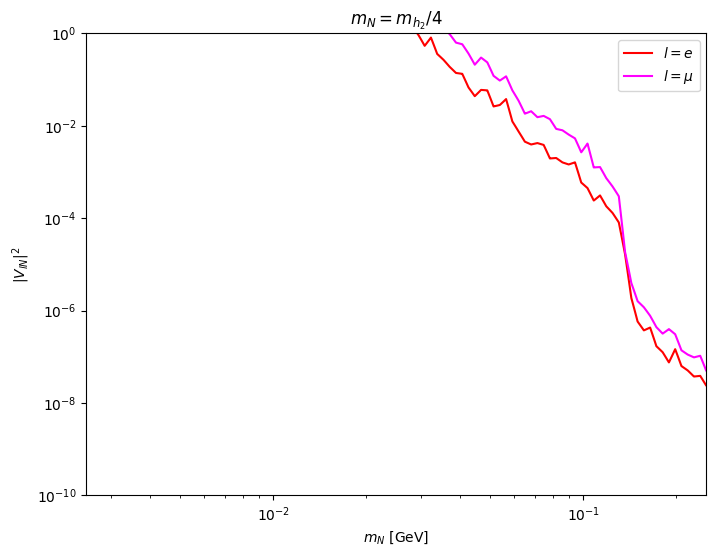

In [14]:
setups = [ 
    ["e_mixing_front_ship_4", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_mixing_front_ship_4", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses/4, couplings**2)
    n = np.log10(np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_N$ [GeV]") 
    plt.ylabel(r"$|V_{lN}|^2$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(0.25e-2, 0.25)
    plt.ylim(1e-10, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_mixing_front_4"+".pdf")

/tmp/ipykernel_11017/355754921.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


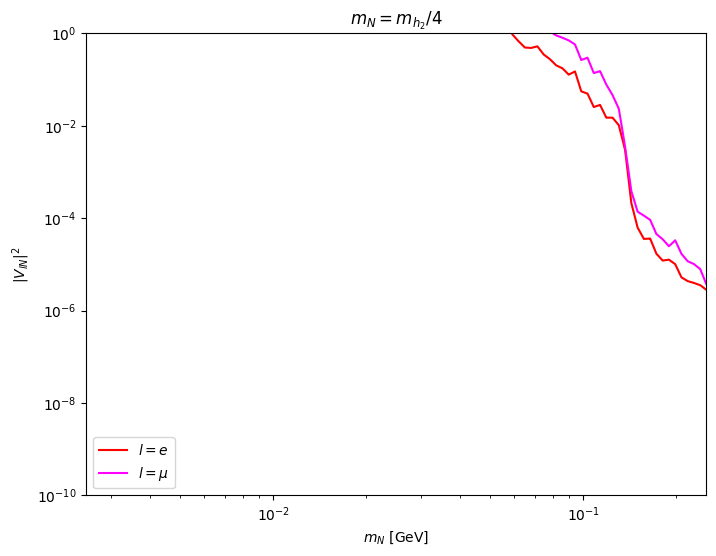

In [12]:
setups = [ 
    ["e_mixing_front_ship_5", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_mixing_front_ship_5", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses/4, couplings**2)
    n = np.log10(np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_N$ [GeV]") 
    plt.ylabel(r"$|V_{lN}|^2$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(0.25e-2, 0.25)
    plt.ylim(1e-10, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend(loc="lower left")
plt.savefig("bounds_400GeV_mixing_front_5"+".pdf")

/tmp/ipykernel_11017/1587793869.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


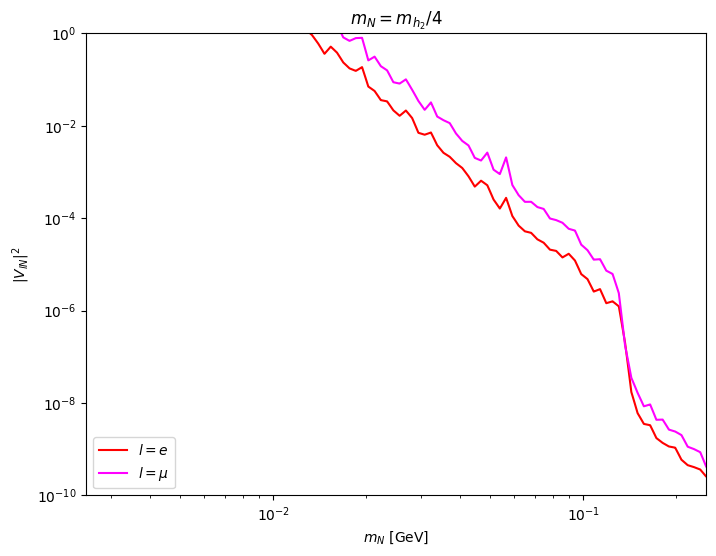

In [13]:
setups = [ 
    ["e_mixing_front_ship_3", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_mixing_front_ship_3", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses/4, couplings**2)
    n = np.log10(np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_N$ [GeV]") 
    plt.ylabel(r"$|V_{lN}|^2$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(0.25e-2, 0.25)
    plt.ylim(1e-10, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend(loc="lower left")
plt.savefig("bounds_400GeV_mixing_front_3"+".pdf")

/tmp/ipykernel_11017/3444774602.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


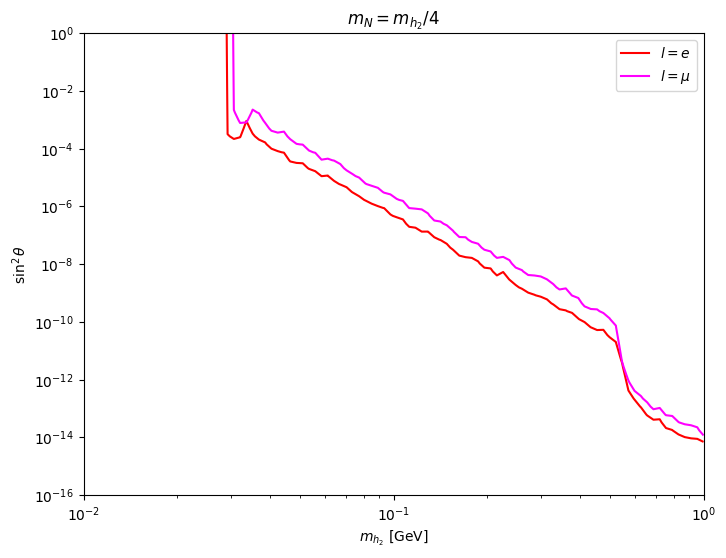

In [15]:
setups = [ 
    ["e_coupling_front_ship_3", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_coupling_front_ship_3", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses, couplings**2)
    n = np.log10(1e4*np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_{h_2}$ [GeV]") 
    plt.ylabel(r"$\sin^2 \theta$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(1e-2, 1)
    plt.ylim(1e-16, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_coupling_front_3"+".pdf")

/tmp/ipykernel_11017/425716791.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


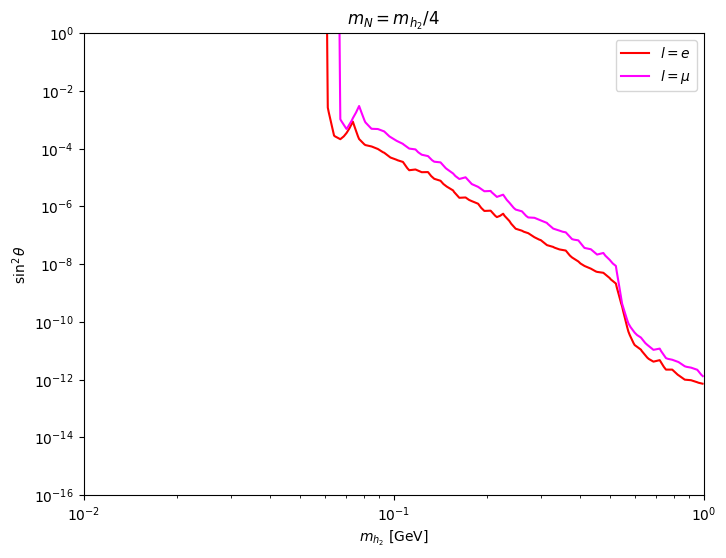

In [16]:
setups = [ 
    ["e_coupling_front_ship_4", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_coupling_front_ship_4", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses, couplings**2)
    n = np.log10(1e4*np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_{h_2}$ [GeV]") 
    plt.ylabel(r"$\sin^2 \theta$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(1e-2, 1)
    plt.ylim(1e-16, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_coupling_front_4"+".pdf")

In [8]:
foresee.set_detector(
    distance=70, 
    selection="abs(x.x)<3 and abs(x.y)<6", 
    length=50, unit=unit,
    luminosity=6e20/1.085e15, name="U1_X",
)

For our benchmark point, let us now look at how many particle decay inside the decay volume. We also export 1000 unweighted events as a HEPMC file. 

Let us plot the resulting energy distribution

## 3. Sensitivity Reach

In the following, we will obtain the projected sensitivity for the LLP model. For this, we first define a grid of couplings and masses, and then produce the corresponding fluxes. 

We can now plot the `production rate vs mass` using the `foresee.plot_production()` function.

Let us now scan over various masses and couplings, and record the resulting number of evets. Note that here we again consider the FASER2 configuration, which we set up before.

In [19]:
%%time
#get reach 
couplings = np.logspace(-15, 0, 110)
configuration, exp ='coupling_back', 'ship'

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=1, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"3.npy",result)

list_nevents = []
for mass in masses: 
    nevents, _  = foresee.coup_event(mass, energy, N=2, couplings=couplings, g=0.01, U=1e-3, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,couplings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"3.npy",result)

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 4min 56s, sys: 92.1 ms, total: 4min 56s
Wall time: 4min 56s


In [20]:
%%time
#get reach 
mixings = np.logspace(-10, 0, 500)
configuration, exp ='mixing_back', 'ship'

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=1, Us=mixings, g=0.01, coup=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_e_"+configuration+"_"+exp+"4.npy",result)

list_nevents = []
for mass in masses: #
    nevents, _  = foresee.mix_event(mass, energy, N=2, Us=mixings, g=0.01, coup=1e-4, mN = 1/4, preselectioncuts="None", sample=10)
    list_nevents.append(nevents)  
        
#save results

result = [masses,mixings,list_nevents]
np.save("model/results/"+energy+unit+"_mu_"+configuration+"_"+exp+"4.npy",result)

CPU times: user 1min 1s, sys: 12 ms, total: 1min 1s
Wall time: 1min 1s


We can now plot the results. For this, we first specify all detector setups for which we want to show result (filename in model/results directory, label, color, linestyle, opacity alpha for filled contours, required number of events).

/tmp/ipykernel_11017/332731324.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


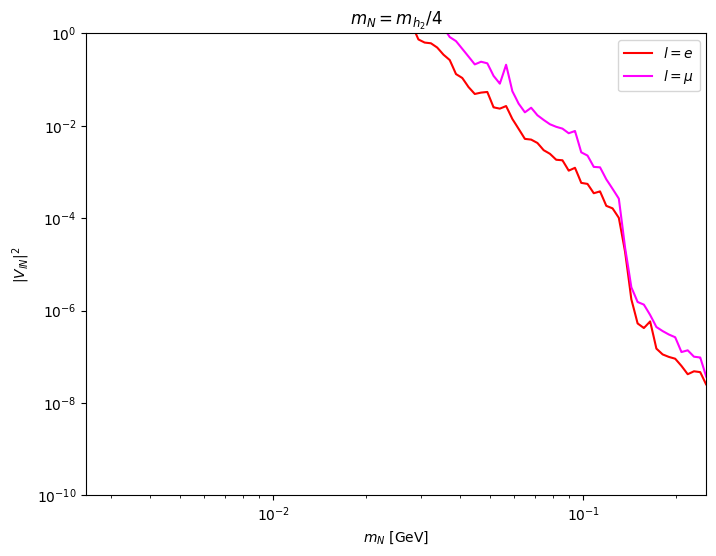

In [17]:
setups = [ 
    ["e_mixing_back_ship_4", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_mixing_back_ship_4", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses/4, couplings**2)
    n = np.log10(np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_N$ [GeV]") 
    plt.ylabel(r"$|V_{lN}|^2$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(0.25e-2, 0.25)
    plt.ylim(1e-10, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_mixing_back_4"+".pdf")

/tmp/ipykernel_11017/4231237537.py:12: UserWarning: The following kwargs were not used by contour: 'clabel'
  plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


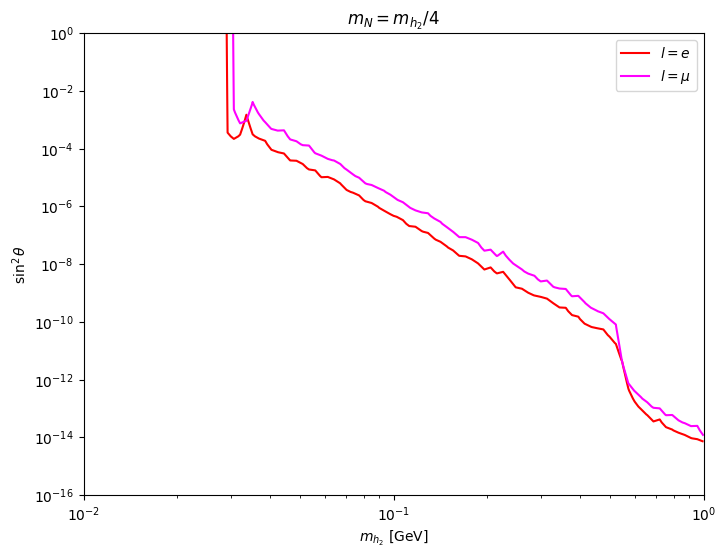

In [18]:
setups = [ 
    ["e_coupling_back_ship_3", r"$l=e$", "red"     ,  "solid"  , 0., 3],
    ["mu_coupling_back_ship_3", r"$l=\mu$"    , "magenta" ,  "solid"  , 0., 3],
]

for setup in setups:
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load("model/results/400GeV_"+filename+".npy", allow_pickle=True, encoding='latin1')
    # print(nsignals.T+1e-20)
    m, c = np.meshgrid(masses, couplings**2)
    n = np.log10(1e4*np.array(nsignals).T+1e-20)
    plt.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    plt.plot([0],[0],label=label, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$m_{h_2}$ [GeV]") 
    plt.ylabel(r"$\sin^2 \theta$")
    plt.rcParams["figure.figsize"]=(8,6)
    plt.xlim(1e-2, 1)
    plt.ylim(1e-16, 1)
    plt.title(r"$m_N = m_{h_2}/4$")
plt.legend()
plt.savefig("bounds_400GeV_coupling_back_3"+".pdf")